In [3]:
import torch
import torchvision
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"GPU dostępne: {torch.cuda.is_available()}")

PyTorch: 2.12.0+cpu
Torchvision: 0.27.0+cpu
GPU dostępne: False


In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import os

In [9]:
data_dir = r'C:\Users\Akadia Sobanska\Documents\AI_Data_Scientist\ML_picture_recognition_Adam_project\melanoma_segmentation\data\melanoma_cancer_dataset\train'

In [10]:
benign_img = Image.open(os.path.join(data_dir, 'benign', os.listdir(os.path.join(data_dir, 'benign'))[0]))
malignant_img = Image.open(os.path.join(data_dir, 'malignant', os.listdir(os.path.join(data_dir, 'malignant'))[0]))

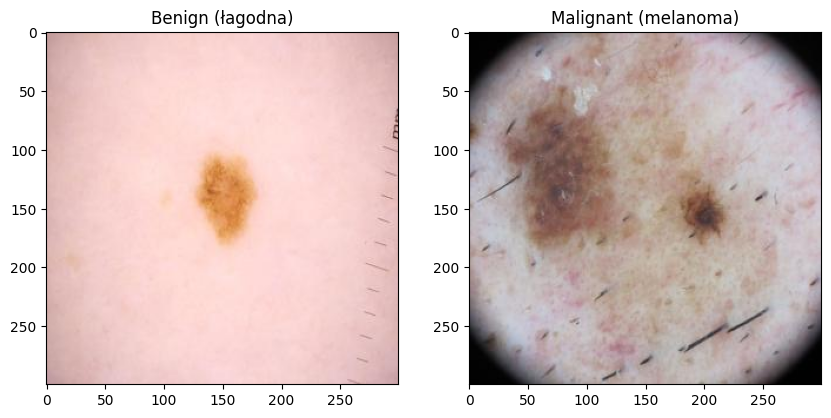

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(benign_img)
axes[0].set_title('Benign (łagodna)')
axes[1].imshow(malignant_img)
axes[1].set_title('Malignant (melanoma)')
plt.show()

In [12]:
benign_count = len(os.listdir(os.path.join(data_dir, 'benign')))
malignant_count = len(os.listdir(os.path.join(data_dir, 'malignant')))

print(f'Benign:    {benign_count} zdjęć')
print(f'Malignant: {malignant_count} zdjęć')
print(f'Razem:     {benign_count + malignant_count} zdjęć')

Benign:    5000 zdjęć
Malignant: 4605 zdjęć
Razem:     9605 zdjęć


In [13]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [14]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [15]:
# wczytaj dane
train_dataset = ImageFolder(root=data_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f'Klasy: {train_dataset.classes}')
print(f'Liczba batchy: {len(train_loader)}')

Klasy: ['benign', 'malignant']
Liczba batchy: 301


In [16]:
import torch.nn as nn
from torchvision import models

# załaduj gotowy model EfficientNet z wagami ImageNet
model = models.efficientnet_b0(weights='IMAGENET1K_V1')

# zmień ostatnią warstwę na naszą (2 klasy: benign/malignant)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Akadia Sobanska/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100.0%


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [17]:
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [18]:
import torch.optim as optim

device = torch.device('cpu')
model = model.to(device)

# funkcja straty i optymalizator
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print('Model gotowy do trenowania')

Model gotowy do trenowania


In [19]:
epochs = 3  # na start tylko 3 epoki żeby zobaczyć czy działa

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    print(f'Epoka {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Accuracy: {accuracy:.2f}%')

Epoka 1/3 | Loss: 0.2260 | Accuracy: 91.12%
Epoka 2/3 | Loss: 0.1784 | Accuracy: 93.03%
Epoka 3/3 | Loss: 0.1635 | Accuracy: 93.61%


In [20]:
test_dir = r'C:\Users\Akadia Sobanska\Documents\AI_Data_Scientist\ML_picture_recognition_Adam_project\melanoma_segmentation\data\melanoma_cancer_dataset\test'

test_dataset = ImageFolder(root=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

print(f'Accuracy na danych testowych: {100 * correct / total:.2f}%')

Accuracy na danych testowych: 92.00%


In [21]:
torch.save(model.state_dict(), r'C:\Users\Akadia Sobanska\Documents\AI_Data_Scientist\ML_picture_recognition_Adam_project\melanoma_segmentation\models\melanoma_model.pth')
print('Model zapisany!')

Model zapisany!
